In [1]:
from DynamicModel import DynamicModel
from mod_stefan import StefanSolver
import logging
import numpy as np
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
math_vars = {
    'c_p': 4200,  # Specific heat capacity in J/(kg*K)
    'kappa': 0.6,  # Thermal conductivity in W/(m*K)
    'rho': 1000,  # Density in kg/m^3
    'T_l': 300,  # Liquid temperature in K
    'T_m': 273,  # Melting temperature in K
    'h_m': 100000,  # Enthalpy of melting in J/kg
    'timestep': 0.5,
}

model = DynamicModel(math_vars)
solver = StefanSolver(model)
model.set_solver(StefanSolver)
model.set_nondim_consts(
    #ref_l = 'x_L',
    ref_rho = 'rho',
    ref_kappa = 'kappa',
    ref_c_p = 'c_p',
    alpha = lambda ref_kappa, ref_rho, ref_c_p: ref_kappa / (ref_rho * ref_c_p)
)

name_vars = {
    'x_dat': "X (m)",
    'y_dat': "Y (m)",
    'T': "Temperature (K)",
    "vof_ice": "Solid Volume Fraction of h2o",
    #'interface': 'vof_def'
}

dir_list = [
    r'C:/Users/harsh/Desktop/pix/stefan/5e-3',
    r'C:/Users/harsh/Desktop/pix/stefan/2e-3',
    r'C:/Users/harsh/Desktop/pix/stefan/1e-3',
    r'C:/Users/harsh/Desktop/pix/stefan/5e-4',
]
name = 'data_table_'
name_append = '.csv'

el_vol = [ 5E-6, 2E-6, 1E-6, 2.5E-7]

h_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(
                            dir=path,
                            name=name,
                            name_append=name_append,
                            name_vars=name_vars,
                            timestep_from_file= True,
                            sort_by = "x_dat",
                            #ref_t=lambda ref_l, ref_u: ref_l/ref_u,
                            update_params=False)
    cur_h_data = {}
    analytical_interface = solver.interface_position(t_all = model.params['timesteps'])
    num_interface = solver.calculate_approx_interface_location()
    model.params['el_vol'] = el_vol[idx]
    L_inf, L2, err_abs = solver.calculate_errors()
    cur_h_data = {
        'name': path.split('/')[-1],
        'timesteps': model.params['timesteps'],
        "num_interface": num_interface,
        "analytical_interface": analytical_interface,
        "L_inf": L_inf,
        "L2": L2,
    }
    cur_h_data.update({"abs_err": np.abs(np.subtract(cur_h_data['num_interface'], cur_h_data['analytical_interface']))})
    #cur_h_data.update(model.analysis_data)
    h_data.append(cur_h_data)



d:\thesis\mod_stefan.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root, = fsolve(f_lam, lam_init)
d:\thesis\mod_stefan.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root, = fsolve(f_lam, lam_init)
d:\thesis\mod_stefan.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root, = fsolve(f_lam, lam_init)
d:\thesis\mod_stefan.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root, = fsolve(f_lam, lam_init)


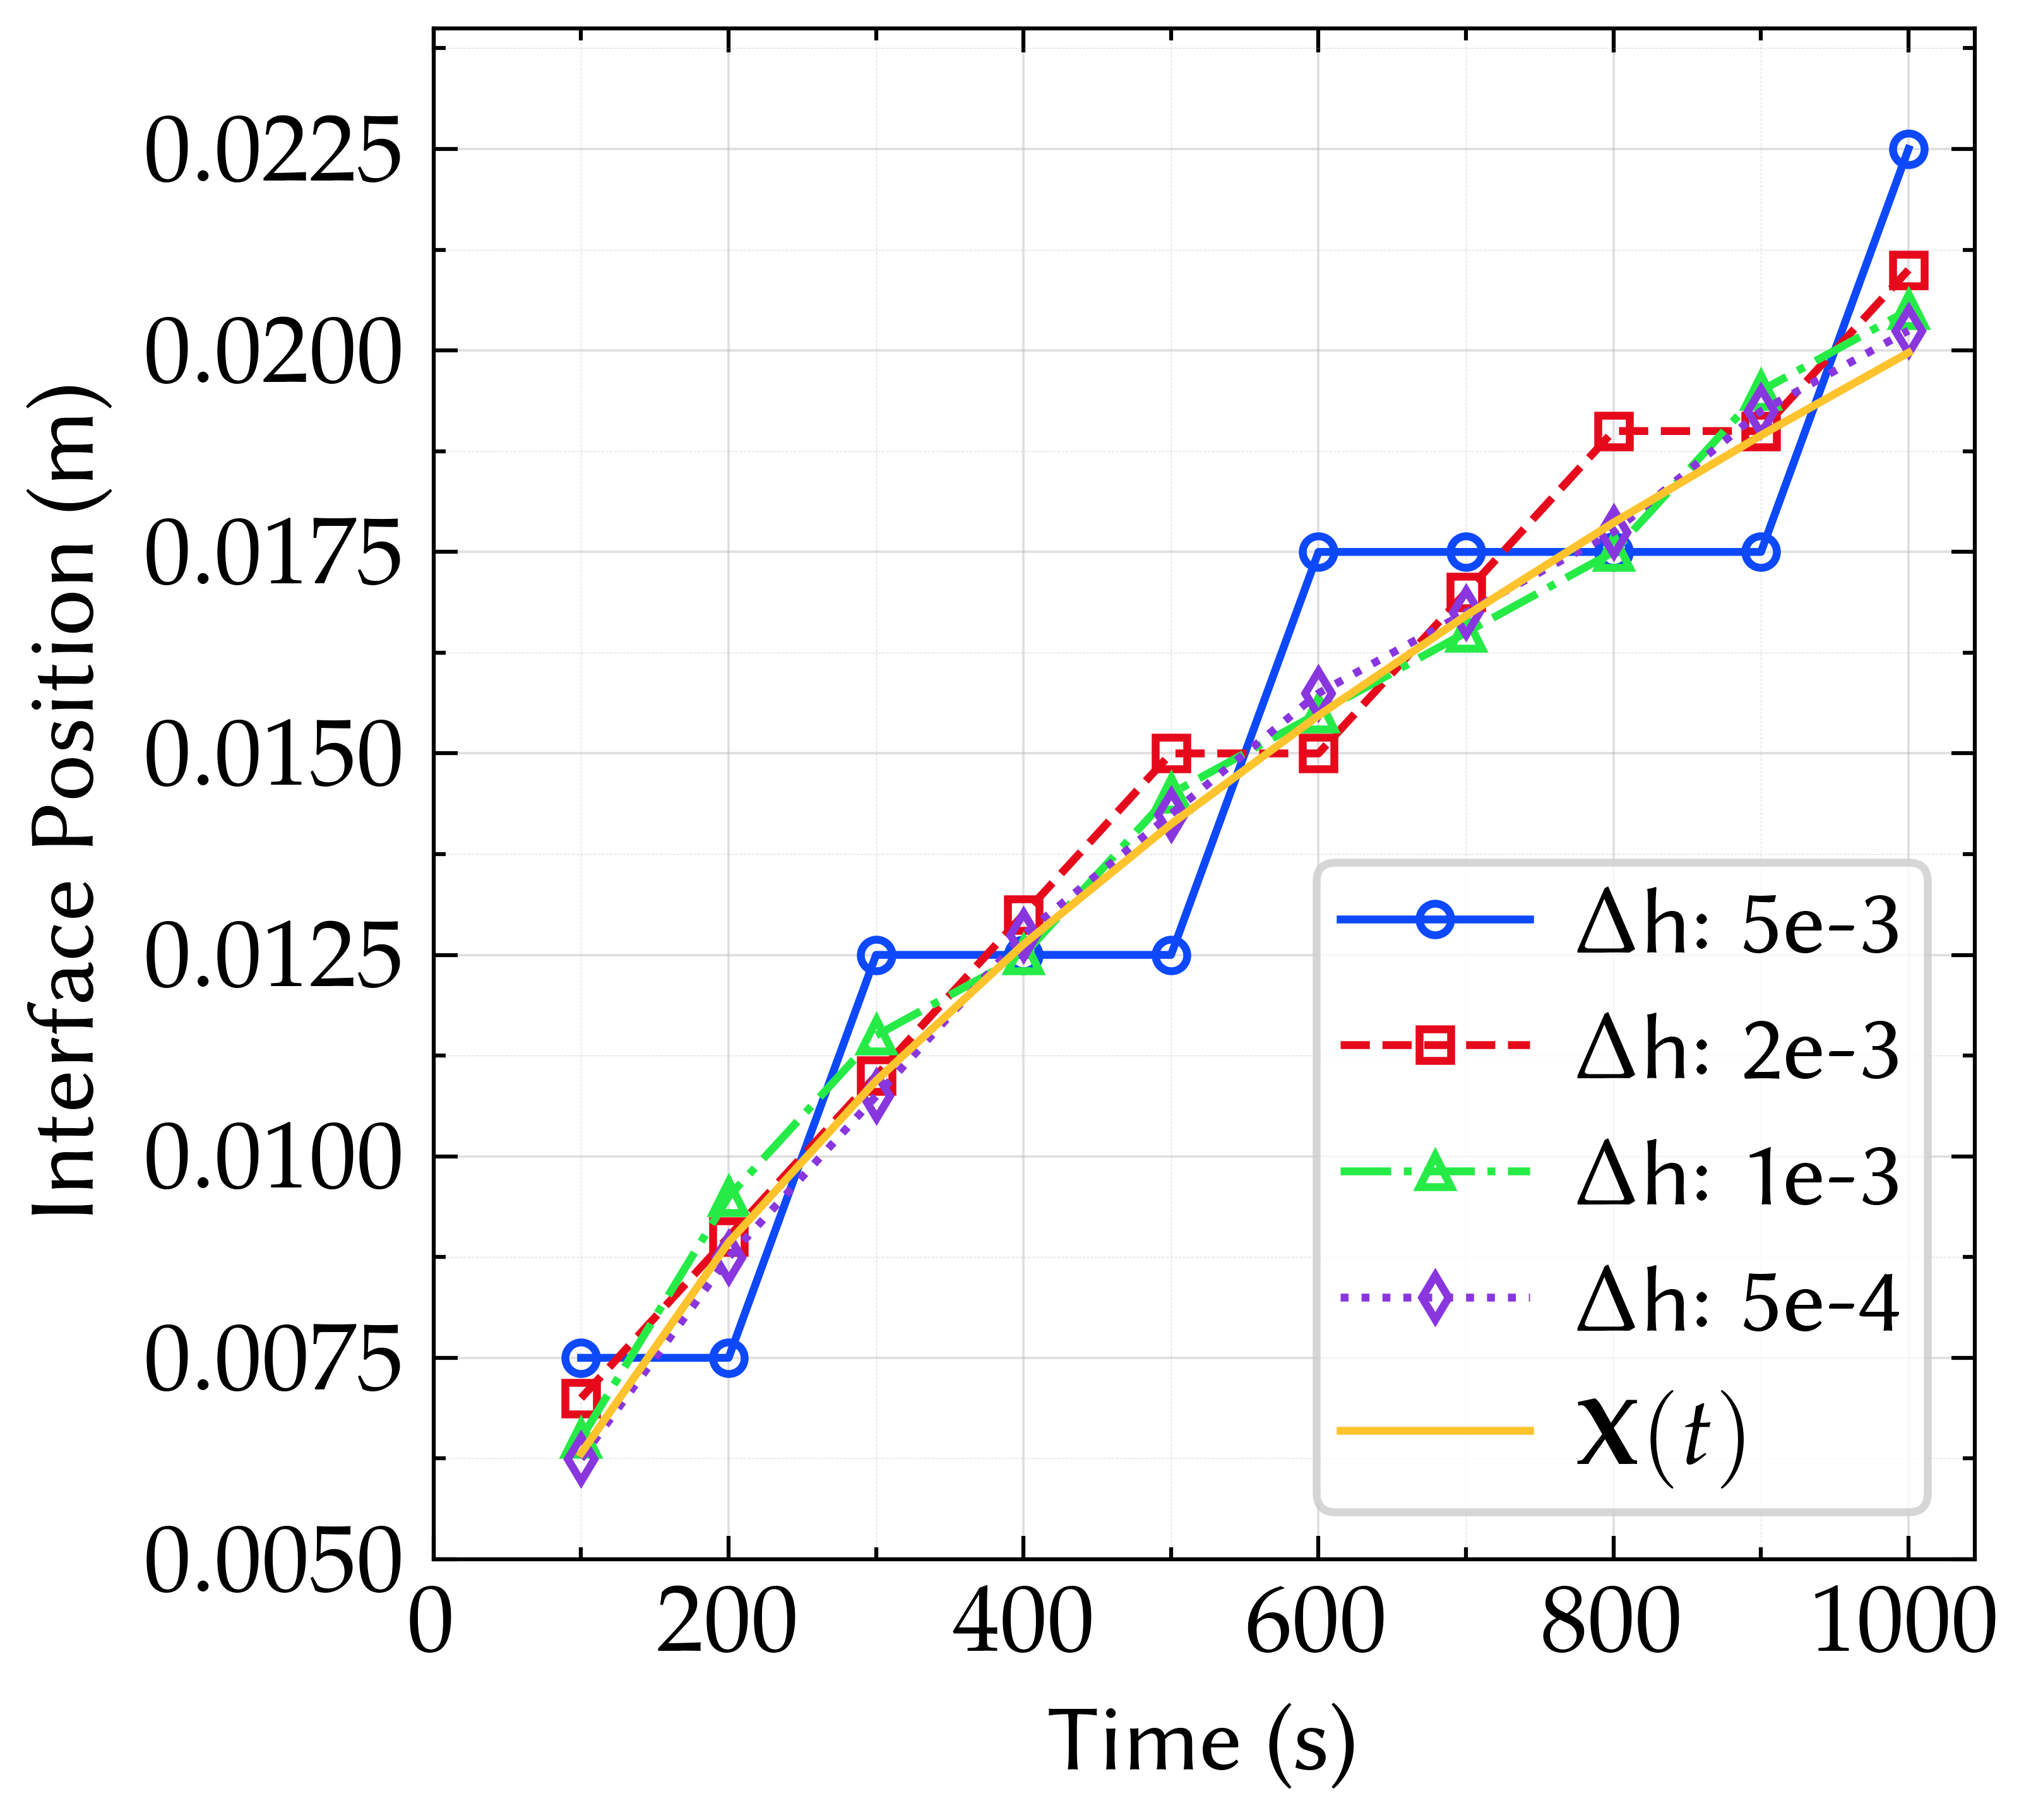

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle  

# ───────────────── global style ───────────────────────────────────
#plt.style.use(['grid'])
plt.style.use(['high-vis'])

with plt.style.context('science-modern'):
    plt.style.use(['high-vis'])
    fig, ax = plt.subplots(figsize=(3.5,3.5), dpi=900)
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    lstyle = cycle(['-', '--', '-.', ':', '-', '--']) 
    for idx, h in enumerate(h_data):
        ax.plot(h['timesteps'], h['num_interface'], marker = next(marks), markersize = 4, linestyle= next(lstyle), linewidth = 1, markerfacecolor='none', label=r"$\Delta \text{h}$" + f": {h['name']}")
    ax.plot(h_data[0]['timesteps'], h_data[0]['analytical_interface'], linewidth = 1, label=r"$\mathbf{X}(t)$")



    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Interface Position (m)")
    ax.set_ylim(0.0050, 0.024)
    ax.set_xlim(0, None)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.00125))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
    legend_box = ax.legend(
        frameon=True,
        #prop={'family': 'sans-serif', 'size': 10, 'weight': 'bold'},
        loc = "lower right"
    )
    ax.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(ax.get_xticklabels(), fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=12)
    plt.show()

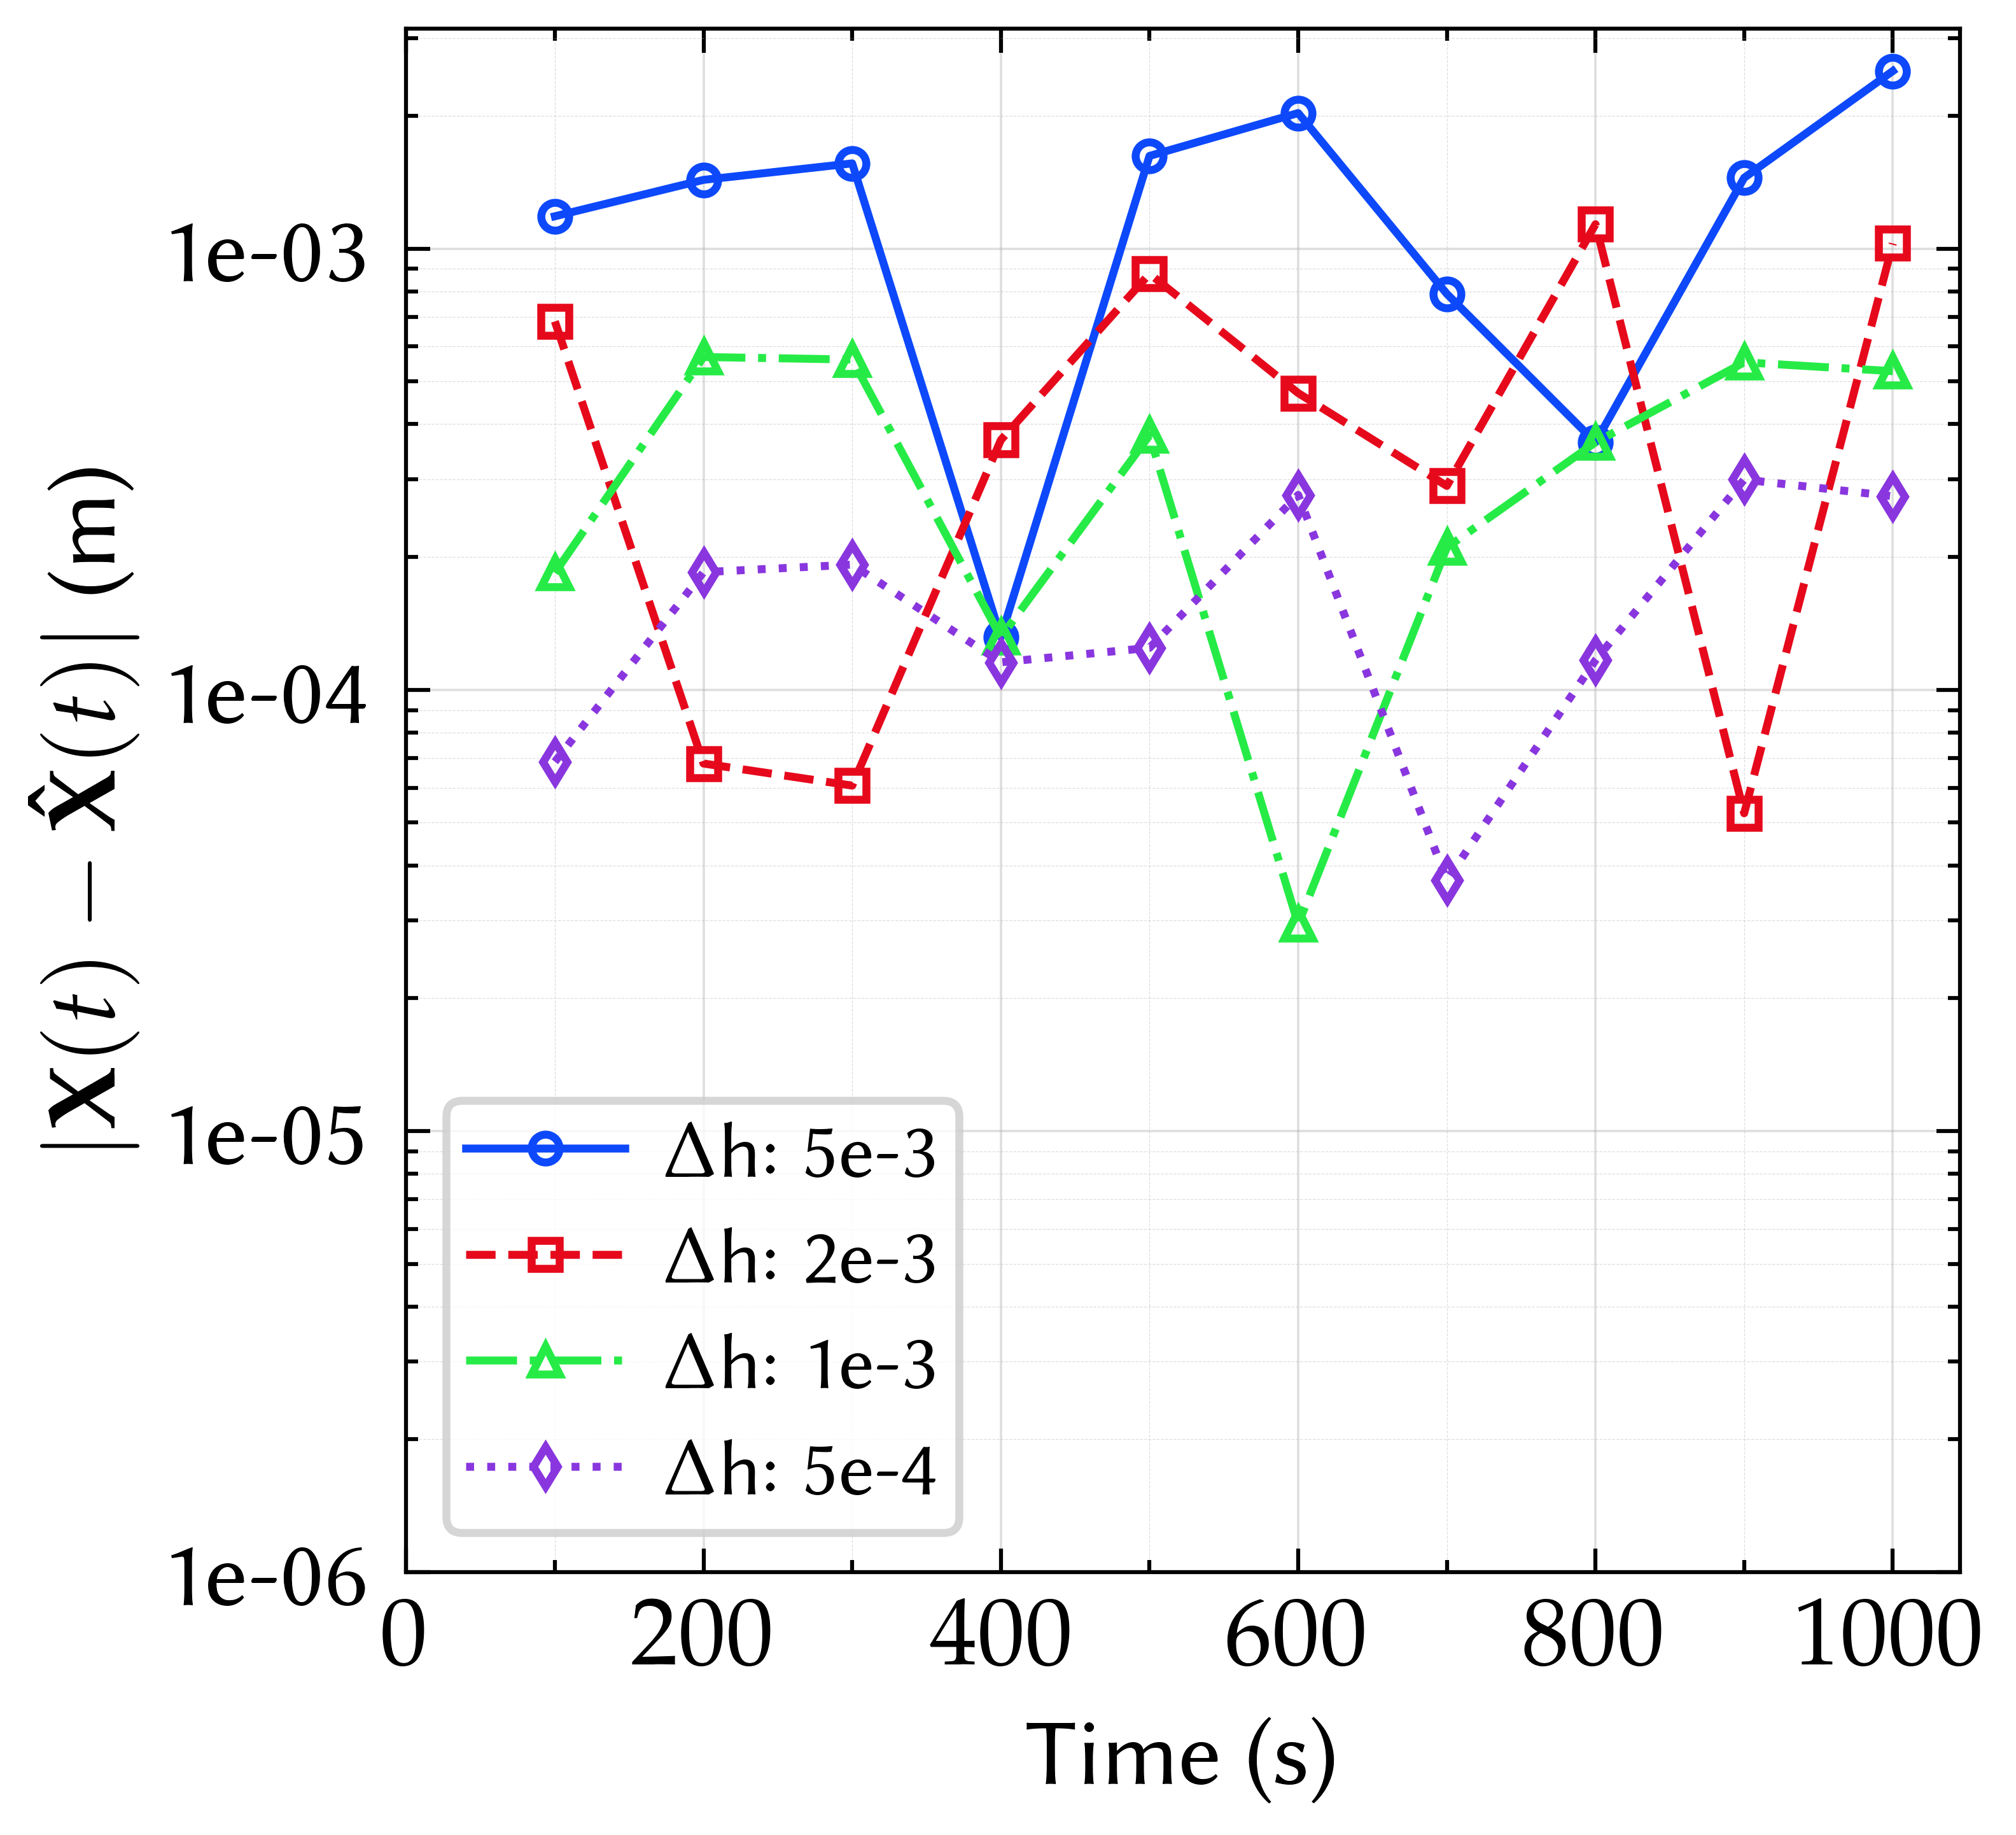

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle  
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, FormatStrFormatter
# ───────────────── global style ───────────────────────────────────

with plt.style.context('science-modern'):
    plt.style.use(['high-vis'])
    fig, ax = plt.subplots(figsize=(3.5,3.5), dpi=900)
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    for h in h_data:
        ax.plot(h['timesteps'], h['abs_err'], marker = next(marks), markersize = 3.5, linewidth = 1, markerfacecolor='none', label=r"$\Delta \text{h}$" + f": {h['name']}")
    # --- make sure 1e-5 (10⁻⁵) is in view and rendered --------------
    ax.set_yscale('log')
    ax.set_ylim(1e-6, None)                               # LOWER LIMIT
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=12))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%1.0e'))
    ax.set_xlim(0, None)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))

    label_font = {'fontsize': 12,}# 'fontfamily': 'Arial', 'weight': 'bold'}
    ax.set_xlabel(r"Time (s)", **label_font)
    ax.set_ylabel(r"$|\mathbf{X}(t) - \mathbf{\hat{X}}(t)|$ (m)", **label_font)

    legend_box = ax.legend(
        frameon=True,
        prop={'size': 10,},
        loc = "lower left"
    )
    ax.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(ax.get_xticklabels(), fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=12)
    #ax.grid(True)
    plt.show()

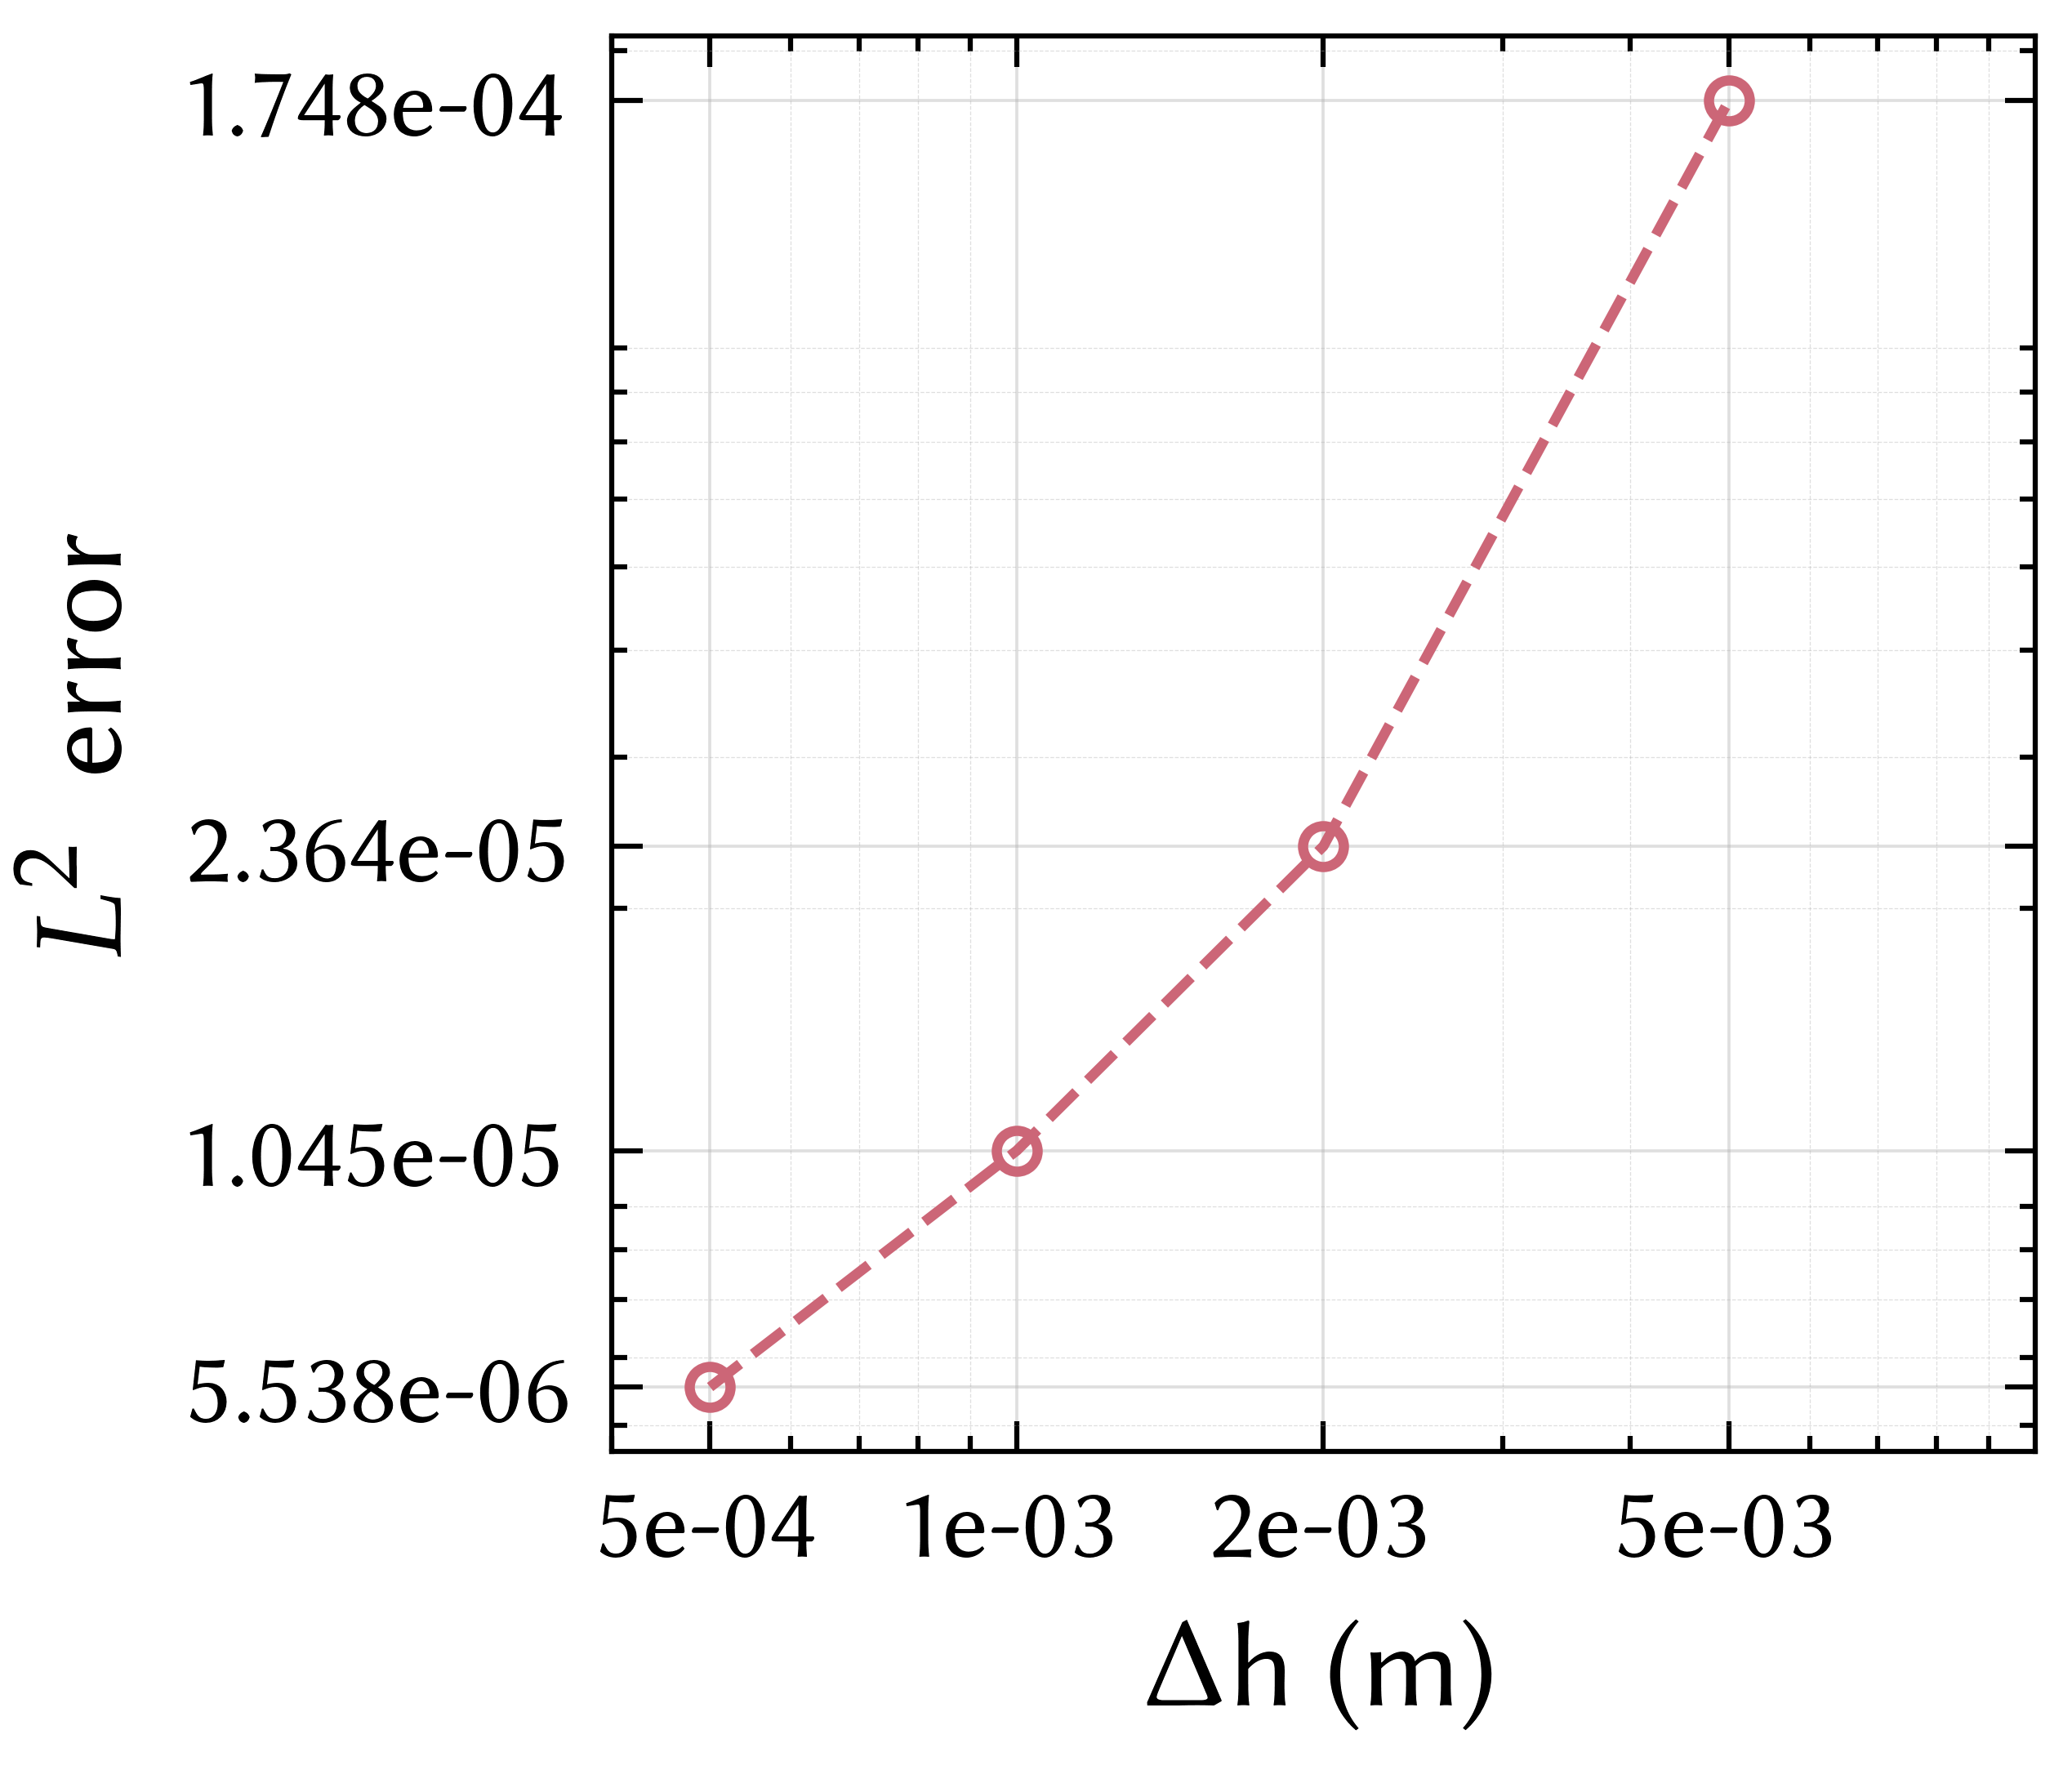

In [5]:
# ─── data for single curve ───────────────────────────────────────────────
x_vals = np.array([float(h['name']) for h in h_data])
y_vals = np.array([np.mean(h['L2'])   for h in h_data])

# make sure they are ordered (optional, but nice on a log axis)
order  = np.argsort(x_vals)
x_vals = x_vals[order]
y_vals = y_vals[order]
with plt.style.context('science-modern'):
    plt.style.use(['muted'])
    fig, ax = plt.subplots(figsize=(2.5,2.5), dpi=900)
# ─── figure / axis ───────────────────────────────────────────────────────

    ax.plot(x_vals, y_vals, linestyle='--', markersize = 4, linewidth = 1, markerfacecolor='none', marker='o')

    # log scales -------------------------------------------------------------
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(4e-4, 1e-2)

    # custom x-ticks ---------------------------------------------------------
    ax.set_xticks(x_vals)                                    # positions
    ax.set_xticklabels([f"{v:.0e}" for v in x_vals])         # nice labels
    y_sorted = np.sort(y_vals)                               # ascending order
    ax.set_yticks(y_sorted)                                  # positions
    ax.set_yticklabels([f"{v:.3e}" for v in y_sorted])  

    # labels -----------------------------------------------------------------
    ax.set_xlabel(r"$\Delta \text{h}$ (m)",  fontsize=12)
    ax.set_ylabel(r"$L^{2}\,\,\,\text{error}$",  fontsize=12)

    # grid -------------------------------------------------------------------

    ax.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    plt.setp(ax.get_xticklabels(), fontsize=10)
    plt.setp(ax.get_yticklabels(), fontsize=10)
    #ax.grid(True)
    plt.show()